In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Datasets/seattleweather1948-2017_1738467795684.csv")
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 998.2+ KB


In [4]:
df.shape

(25551, 5)

In [5]:
df.dropna(inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25548 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25548 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25548 non-null  int64  
 3   TMIN    25548 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 1.2+ MB


{'whiskers': [<matplotlib.lines.Line2D at 0x178dec5ccd0>,
 'caps': [<matplotlib.lines.Line2D at 0x178dec5f610>,
 'boxes': [<matplotlib.lines.Line2D at 0x178de907250>],
 'medians': [<matplotlib.lines.Line2D at 0x178dec5f890>],
 'fliers': [<matplotlib.lines.Line2D at 0x178dec5f9d0>],
 'means': []}

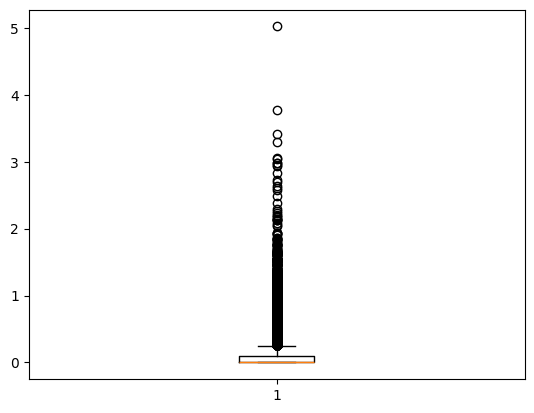

In [7]:
plt.boxplot(df['PRCP'])

In [8]:
# function for show outliers
def showOutliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)
    # print("Upper : " ,upper)
    # print("Lower : ", lower)
    return data[(data[col] < lower) | (data[col] > upper)]
    

In [9]:
def handleOutliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3 - q1
    
    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)
    
    df[col] = df.loc[df[col] > upper , col] = upper
    df[col] = df.loc[df[col] < lower , col] = lower

In [10]:
showOutliers(df, 'PRCP')

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
5,1948-01-06,0.44,48,39,True
...,...,...,...,...,...
25528,2017-11-22,0.52,68,56,True
25534,2017-11-28,0.68,47,43,True
25536,2017-11-30,0.27,46,41,True
25537,2017-12-01,0.27,48,38,True


In [11]:
handleOutliers(df, 'PRCP')

In [12]:
showOutliers(df, 'PRCP')

,DATE,PRCP,TMAX,TMIN,RAIN


{'whiskers': [<matplotlib.lines.Line2D at 0x178deb1c910>,
 'caps': [<matplotlib.lines.Line2D at 0x178deb1cb90>,
 'boxes': [<matplotlib.lines.Line2D at 0x178deb1c7d0>],
 'medians': [<matplotlib.lines.Line2D at 0x178deb1ce10>],
 'fliers': [<matplotlib.lines.Line2D at 0x178deb1cf50>],
 'means': []}

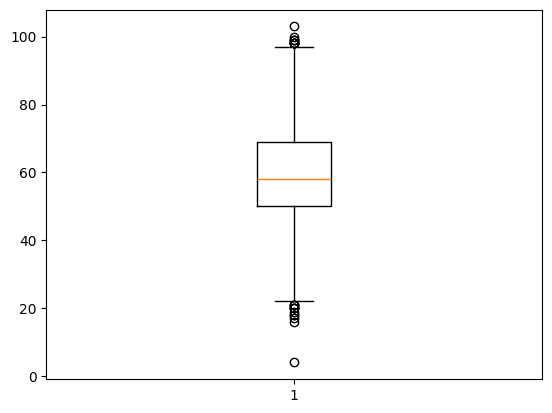

In [13]:
plt.boxplot(df['TMAX'])

In [14]:
showOutliers(df, 'TMAX')

,DATE,PRCP,TMAX,TMIN,RAIN
743,1950-01-13,-0.15,19,11,True
744,1950-01-14,-0.15,16,8,True
745,1950-01-15,-0.15,21,15,True
761,1950-01-31,-0.15,20,0,False
1419,1951-11-20,-0.15,4,39,True
2872,1955-11-12,-0.15,21,13,False
4603,1960-08-08,-0.15,98,66,False
4604,1960-08-09,-0.15,99,59,False
6194,1964-12-16,-0.15,20,10,False
7167,1967-08-16,-0.15,98,59,False


In [15]:
handleOutliers(df, 'TMAX')

In [16]:
showOutliers(df, 'TMAX')

,DATE,PRCP,TMAX,TMIN,RAIN


{'whiskers': [<matplotlib.lines.Line2D at 0x178e0ddc410>,
 'caps': [<matplotlib.lines.Line2D at 0x178e0ddc690>,
 'boxes': [<matplotlib.lines.Line2D at 0x178e0ddc2d0>],
 'medians': [<matplotlib.lines.Line2D at 0x178e0ddc910>],
 'fliers': [<matplotlib.lines.Line2D at 0x178e0ddca50>],
 'means': []}

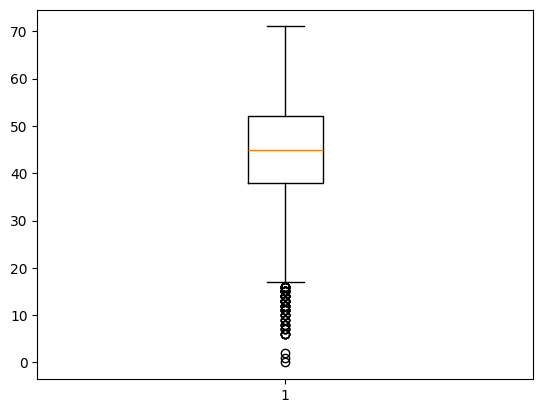

In [17]:
plt.boxplot(df['TMIN'])

In [18]:
showOutliers(df, 'TMIN')

,DATE,PRCP,TMAX,TMIN,RAIN
358,1948-12-24,-0.15,21.5,16,False
374,1949-01-09,-0.15,21.5,13,False
375,1949-01-10,-0.15,21.5,12,False
388,1949-01-23,-0.15,21.5,16,False
393,1949-01-28,-0.15,21.5,16,False
...,...,...,...,...,...
18618,1998-12-22,-0.15,21.5,16,False
22269,2008-12-20,-0.15,21.5,14,True
22624,2009-12-10,-0.15,21.5,16,False
22972,2010-11-23,-0.15,21.5,16,False


In [19]:
handleOutliers(df, 'TMIN')

In [20]:
showOutliers(df, 'TMIN')

,DATE,PRCP,TMAX,TMIN,RAIN


In [21]:
df['RAIN'].value_counts()

RAIN
False    14648
True     10900
Name: count, dtype: int64

In [26]:
df['RAIN'] = df['RAIN'].replace({'True' : 1, 'False' : 0})

C:\Users\User\AppData\Local\Temp\ipykernel_11048\2826192355.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RAIN'] = df['RAIN'].replace({'True' : 1, 'False' : 0})


In [27]:
X = df[['PRCP', 'TMAX', 'TMIN']]
y = df['RAIN']

In [28]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_sm , y_sm = sm.fit_resample(X, y)

In [29]:
y_sm.value_counts()

RAIN
True     14648
False    14648
Name: count, dtype: int64

In [30]:
df.describe()

,PRCP,TMAX,TMIN
count,2.554800e+04,25548.0,25548.0
mean,-1.500000e-01,21.5,17.0
std,2.775612e-17,0.0,0.0
min,-1.500000e-01,21.5,17.0
25%,-1.500000e-01,21.5,17.0
50%,-1.500000e-01,21.5,17.0
75%,-1.500000e-01,21.5,17.0
max,-1.500000e-01,21.5,17.0


In [33]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_ss = ss.fit_transform(X_sm)

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_ss, y_sm, test_size= 0.2, random_state=20)

In [37]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [38]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
test_acc = accuracy_score(y_test, test_pred)
print("Testing Accuracy Score : ", test_acc)

Testing Accuracy Score :  0.4901023890784983


In [42]:
train_acc = accuracy_score(y_train, train_pred)
print("Training Accuracy Score : ", train_acc)

Training Accuracy Score :  0.5024748250554703


In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00      2988
        True       0.49      1.00      0.66      2872

    accuracy                           0.49      5860
   macro avg       0.25      0.50      0.33      5860
weighted avg       0.24      0.49      0.32      5860



C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag